## Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

#### Project Done By - M.Desika

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd 

In [2]:
df = pd.read_csv("online_retail.csv")

### Data Cleaning

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df['CustomerID'].isnull().sum()

np.int64(135080)

In [5]:
df.shape

(541909, 8)

In [6]:
print("Before cleaning:", df.shape)

df = df.dropna(subset=['CustomerID'])
print("After removing missing CustomerID:", df.shape)

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("After removing cancelled invoices:", df.shape)

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print("After removing invalid quantity/price:", df.shape)


Before cleaning: (541909, 8)
After removing missing CustomerID: (406829, 8)
After removing cancelled invoices: (397924, 8)
After removing invalid quantity/price: (397884, 8)


In [7]:
(df['Quantity'] <= 0).sum()

np.int64(0)

In [8]:
(df['UnitPrice'] == 0).sum()

np.int64(0)

In [9]:
# Missing CustomerID
df['CustomerID'].isnull().sum()

# Cancelled invoices
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(0)

In [10]:

df1 = df.copy()
df1.to_csv("online_retail_cleaned.csv", index=False)


In [11]:
(df1['UnitPrice'] == 0).sum()

np.int64(0)

In [12]:
type(df1)


pandas.core.frame.DataFrame

### EDA

In [13]:
df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])
df1['TotalPrice'] = df['Quantity'] * df1['UnitPrice']


In [14]:
country_txn = df1.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False)
country_txn.head(10)


Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: InvoiceNo, dtype: int64

Chart 1 - Top 10 Countries by Number of Transactions

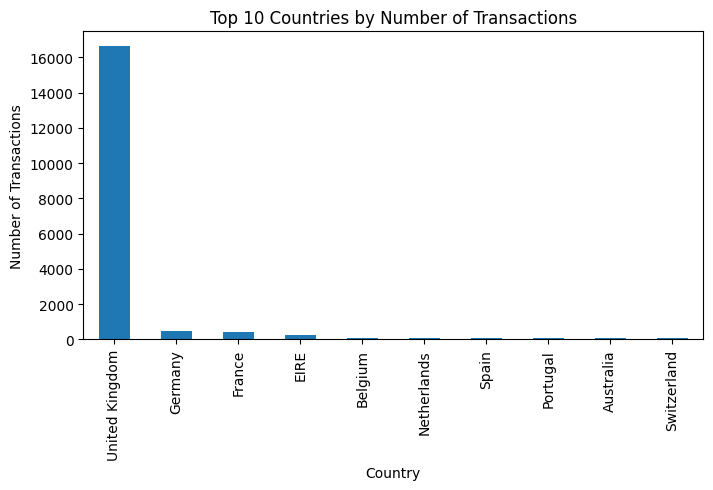

In [15]:
import matplotlib.pyplot as plt

country_txn.head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top 10 Countries by Number of Transactions")
plt.ylabel("Number of Transactions")
plt.xlabel("Country")
plt.show()


Chart 2 - Top 10 Products by Revenue

In [16]:
top_products_qty = (
    df1.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products_qty


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [17]:
top_products_rev = (
    df1.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products_rev


Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64

Chart 3 - Top 10 Products by Revenue

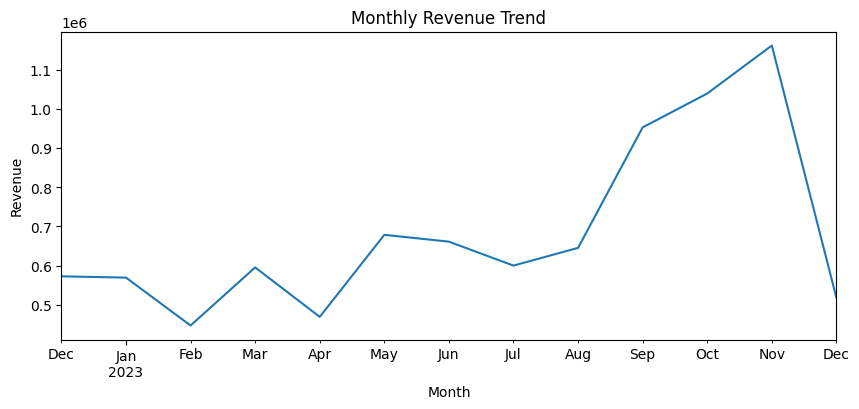

In [18]:
monthly_revenue = df1.groupby(df1 ['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

monthly_revenue.plot(figsize=(10,4))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


Chart 4 - Monetary distribution per transaction 

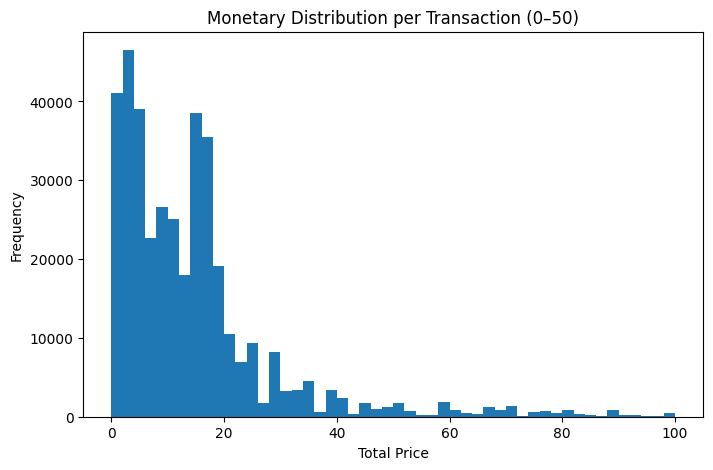

In [19]:
import matplotlib.pyplot as plt

filtered_tv = df1.loc[
    (df1['TotalPrice'] >= 0) & 
    (df1['TotalPrice'] <= 100),
    'TotalPrice'
]

plt.figure(figsize=(8,5))
plt.hist(filtered_tv, bins=50)
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.title('Monetary Distribution per Transaction (0–50)')
plt.show()


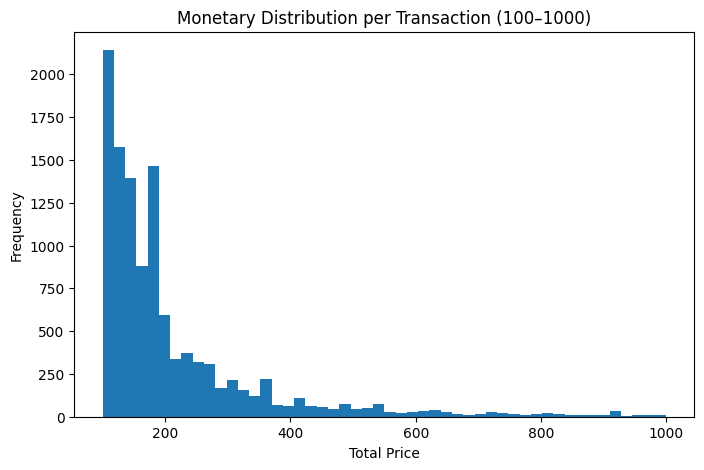

In [20]:
import matplotlib.pyplot as plt

filtered_tv = df1.loc[
    (df1['TotalPrice'] >= 100) & 
    (df1['TotalPrice'] <= 1000),
    'TotalPrice'
]

plt.figure(figsize=(8,5))
plt.hist(filtered_tv, bins=50)
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.title('Monetary Distribution per Transaction (100–1000)')
plt.show()


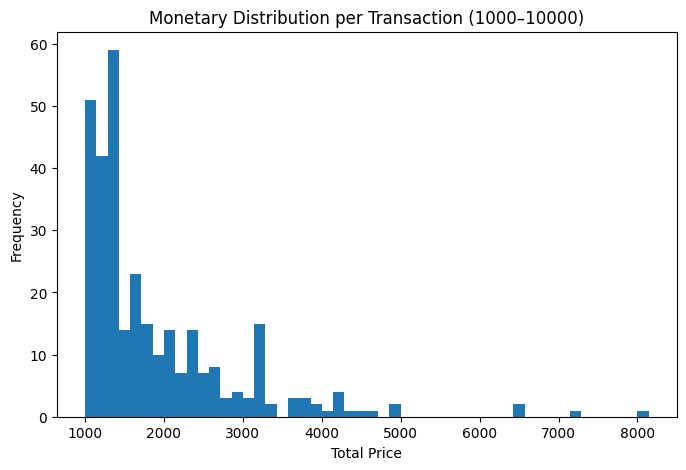

In [21]:
import matplotlib.pyplot as plt

filtered_tv = df1.loc[
    (df1['TotalPrice'] >= 1000) & 
    (df1['TotalPrice'] <= 10000),
    'TotalPrice'
]

plt.figure(figsize=(8,5))
plt.hist(filtered_tv, bins=50)
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.title('Monetary Distribution per Transaction (1000–10000)')
plt.show()


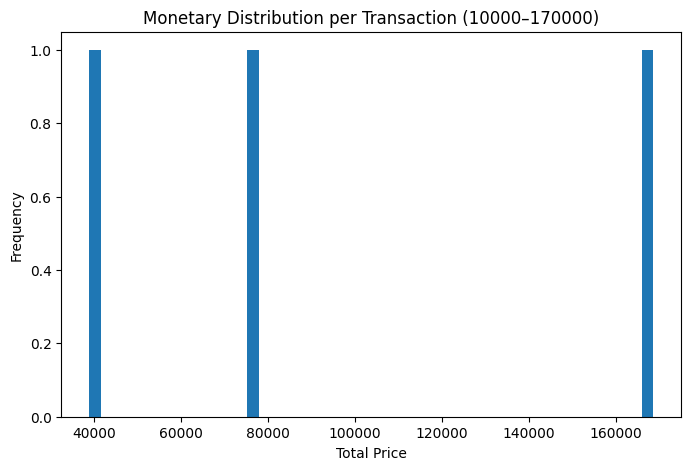

In [22]:
import matplotlib.pyplot as plt

filtered_tv = df1.loc[
    (df1['TotalPrice'] >= 10000) & 
    (df1['TotalPrice'] <= 170000),
    'TotalPrice'
]

plt.figure(figsize=(8,5))
plt.hist(filtered_tv, bins=50)
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.title('Monetary Distribution per Transaction (10000–170000)')
plt.show()


In [23]:
count_0_to_1 = df1[(df1['TotalPrice'] >= 0) & (df1['TotalPrice'] <= 100)].shape
print(count_0_to_1)
df1.shape

(386227, 9)


(397884, 9)

 Insights - Most transactions in the dataset are low-value purchases, with approximately 97% of transactions below a monetary value of 100, confirming a highly skewed spending distribution typical of retail datasets.

Chart 5 - Monetary distribution per customer

In [24]:
customer_monetary = df1.groupby('CustomerID')['TotalPrice'].sum()


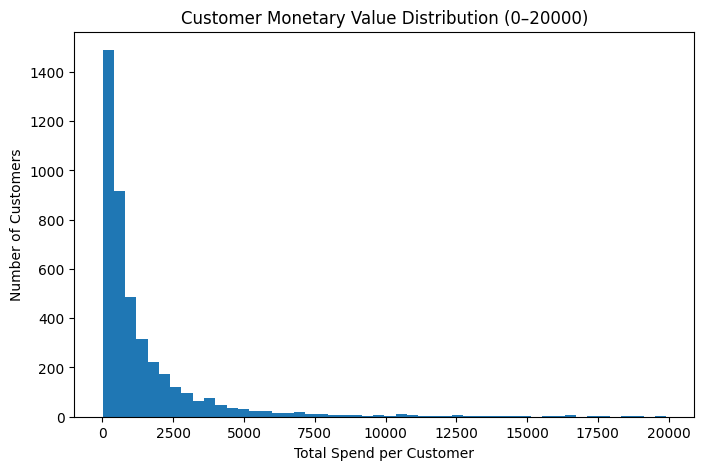

In [25]:
filtered_cm = customer_monetary[
    (customer_monetary >= 0) & (customer_monetary <= 20000)
]
plt.figure(figsize=(8,5))
plt.hist(filtered_cm, bins=50)
plt.title("Customer Monetary Value Distribution (0–20000)")
plt.xlabel("Total Spend per Customer")
plt.ylabel("Number of Customers")
plt.show()


Insights - This histogram shows that customer spending is highly skewed, with most customers contributing low revenue and a small group of high-value customers accounting for large purchases.

Chart 6 - RFM distributions

In [26]:
snapshot_date = df1['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df1.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head(20)


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


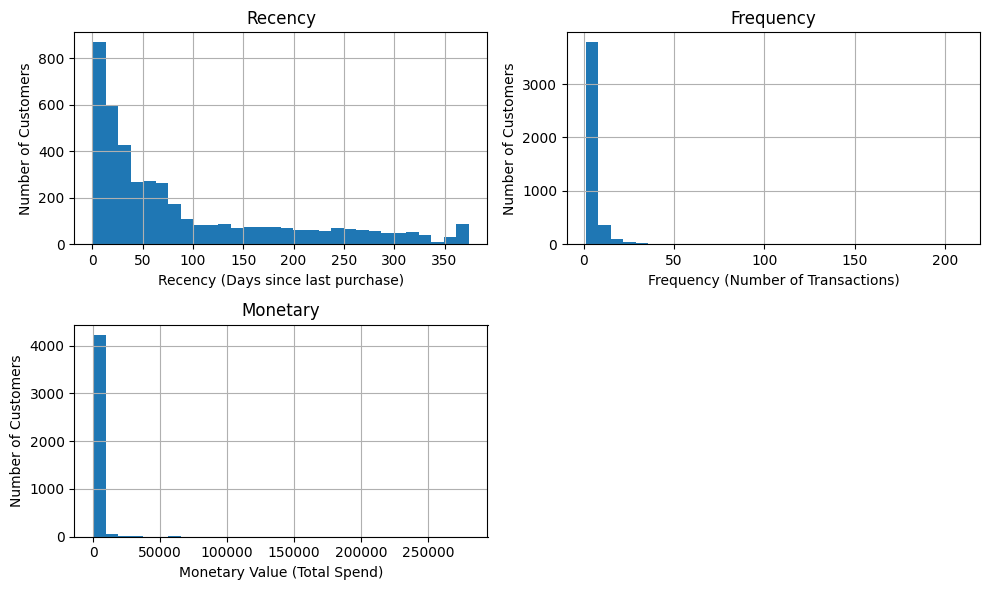

In [27]:
import matplotlib.pyplot as plt

rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=30, figsize=(10,6))

# Recency plot
plt.subplot(2, 2, 1)
plt.xlabel("Recency (Days since last purchase)")
plt.ylabel("Number of Customers")

# Frequency plot
plt.subplot(2, 2, 2)
plt.xlabel("Frequency (Number of Transactions)")
plt.ylabel("Number of Customers")

# Monetary plot
plt.subplot(2, 2, 3)
plt.xlabel("Monetary Value (Total Spend)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


Insights - RFM analysis summarizes customer behavior based on how recently they purchased, how often they purchase, and how much they spend.

Chart 7 - Elbow curve for cluster selection

A scaler standardizes features by computing statistical parameters such as mean and standard deviation and transforming the data so that all features contribute equally to distance-based algorithms.

fit() → computes mean & std

transform() → applies formula

Output → NumPy array with scaled values

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


In [29]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)


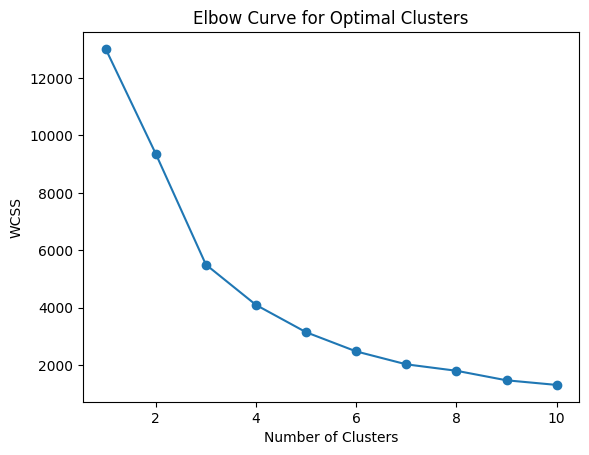

In [30]:
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Curve for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


Insights - The elbow curve indicates that K = 4 is optimal, as WCSS reduction significantly slows beyond this point, suggesting additional clusters do not add meaningful structure.

Chart 8 - Customer Cluster Profiles

In [31]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [32]:
cluster_profile = rfm.groupby('Cluster') .mean()
cluster_profile


,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


Insights - RFM clustering reveals four distinct customer segments, with Cluster 2 representing high-value champions, Cluster 3 loyal customers, Cluster 0 potential loyalists, and Cluster 1 at-risk customers.

Chart 9 - Product Recommendation Heatmap / Similarity Matrix

In [33]:
customer_product = df.pivot_table(
    index='CustomerID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)


In [34]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(customer_product.T)
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)


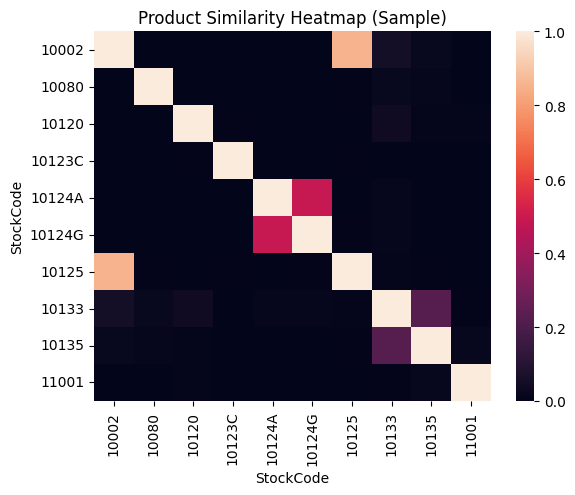

In [35]:
import seaborn as sns

sns.heatmap(product_similarity_df.iloc[:10, :10],color='red')
plt.title("Product Similarity Heatmap (Sample)")
plt.show()


In [36]:
def label_cluster(row):
    if row['Recency'] < 30 and row['Frequency'] > 20 and row['Monetary'] > 10000:
        return 'High-Value'
    elif row['Frequency'] >= 5:
        return 'Regular'
    elif row['Recency'] > 180:
        return 'At-Risk'
    else:
        return 'Occasional'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)
rfm.head()


,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,At-Risk
12347.0,2,7,4310.00,0,Regular
12348.0,75,4,1797.24,0,Occasional
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,1,At-Risk


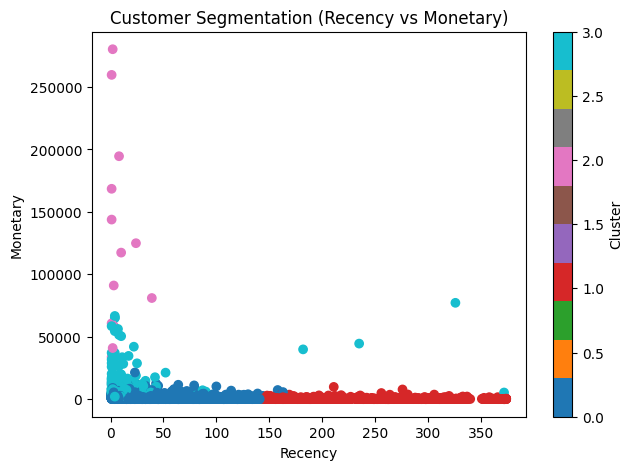

In [37]:
plt.figure(figsize=(7,5))
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='tab10')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segmentation (Recency vs Monetary)')
plt.colorbar(label='Cluster')
plt.show()


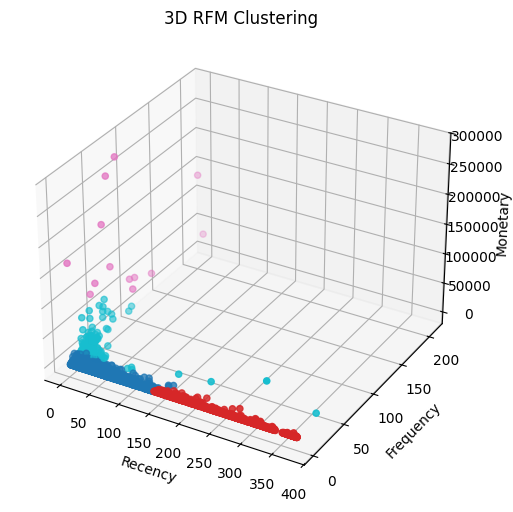

In [38]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='tab10'
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('3D RFM Clustering')
plt.show()


In [39]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(score)


0.616212846765192


The silhouette score of 0.61 indicates strong clustering quality, showing high intra-cluster similarity and clear inter-cluster separation. This confirms that the selected value of k and the RFM features are appropriate for customer segmentation.

### Saving The Model

In [40]:
import joblib

joblib.dump(kmeans, 'rfm_kmeans_model.pkl')
joblib.dump(scaler, 'rfm_scaler.pkl')


['rfm_scaler.pkl']

In [41]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Create interaction matrix
customer_product_matrix = pd.pivot_table(
    df,
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)


In [42]:
# Transpose to Product × Customer
product_customer_matrix = customer_product_matrix.T

# Cosine similarity
product_similarity = cosine_similarity(product_customer_matrix)

# Convert to DataFrame
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)


In [43]:
def recommend_products(product_name, top_n=5):
    if product_name not in product_similarity_df.index:
        return "Product not found"

    similar_scores = product_similarity_df[product_name]
    similar_products = (
        similar_scores
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    return similar_products


In [44]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")


Description
GIN + TONIC DIET METAL SIGN         0.750410
RED HANGING HEART T-LIGHT HOLDER    0.658719
WASHROOM METAL SIGN                 0.643500
LAUNDRY 15C METAL SIGN              0.642206
GREEN VINTAGE SPOT BEAKER           0.631461
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64